In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%%capture
%run '/content/drive/MyDrive/Repos/MachineLearning-ML001/01 Simple Classification Algorithms/1.3.Standardization.ipynb'

### **Large-Scale Machine Learning and Stochastic Gradient Descent (SGD)**

**The Problem with Full Batch Gradient Descent**
Standard gradient descent (Full Batch) calculates the loss gradient from the *entire* training dataset before taking a single step. For large datasets with millions of data points, this becomes computationally expensive because the whole dataset must be reevaluated for every single weight update.

**The Solution: Stochastic Gradient Descent (SGD)**
Also known as iterative or online gradient descent, SGD updates the weights incrementally for *each individual training example* rather than accumulating the errors.

* **Full Batch Update:** Requires summing errors over all examples ($n$):

$$
\Delta w_j = \frac{2\eta}{n} \sum_i \left( y^{(i)} - \sigma(z^{(i)}) \right) x_j^{(i)}
$$

* **SGD Update:** Updates weights for each individual example ($i$):

$$
\Delta w_j = \eta \left( y^{(i)} - \sigma(z^{(i)}) \right) x_j^{(i)}, \quad \Delta b = \eta \left( y^{(i)} - \sigma(z^{(i)}) \right)
$$

**Key Advantages of SGD:**
* **Faster Convergence:** Because weights are updated much more frequently.
* **Escaping Local Minima:** The error surface is noisier since gradients are calculated on single examples. This noise can actually be beneficial, helping the algorithm escape shallow local minima in nonlinear loss functions.
* **Online Learning:** SGD allows models to be trained "on the fly" as new data arrives. This is highly useful for web applications where data continuously streams in. Once the model is updated, the training data can be discarded to save storage.

**Important Implementation Details for SGD:**
1.  **Shuffling:** To obtain satisfying results and prevent cyclic behavior, it is critical to present training data in a random order. The dataset should be shuffled before every epoch.
2.  **Adaptive Learning Rate:** Unlike standard gradient descent, SGD typically does not reach the exact global loss minimum, but rather hovers very close to it. To achieve further "annealing" to the minimum, the fixed learning rate ($\eta$) is often replaced by an adaptive one that decreases over time. A common formula is:

$$\frac{c_1}{[\text{number of iterations}] + c_2}$$
    
*(where $c_1$ and $c_2$ are constants)*

---

### Mini-Batch Gradient Descent
Mini-batch gradient descent serves as a compromise between Full Batch and SGD. It applies the full batch logic to smaller, manageable subsets of the training data (e.g., 32 examples at a time).

**Benefits:**
* Reaches convergence faster than Full Batch due to more frequent updates.
* More computationally efficient than SGD because it replaces the `for` loop over training examples with vectorized operations (like dot products) from linear algebra.

In [ ]:
class AdalineSGD:
  """ADaptive LInear NEuron Classifier.

  Parameters
  ----------
  eta : float
      Learning rate (between 0.0 and 1.0)
  n_iter : int
      Passes over the training dataset
  shuffle : bool (default: True)
      Shuffles training data every epoch if True to prevent cycles.
  random_state : int
      Random number generator seed for random weight initialization.

  Attributes
  ----------
  w_ : 1d-array
      Weights after fitting.
  b_ : Scalar
      Bias unit after fitting.
  losses_ : list
      Mean squared error loss function values averaged over all training examples in each epoch.
  """

  def __init__(self, eta=0.01, n_iter=10, shuffle=True, random_state=None):
    self.eta = eta
    self.n_iter = n_iter
    self.w_initialized = False
    self.shuffle = shuffle
    self.random_state = random_state

  def fit(self, X, y):
    """ Fit training data.

    Parameters
    ----------
    X : {array-like}, shape = [n_examples, n_features]
        Training vectors, where n_examples is the number of examples and n_features is the number of features.
    y : array-like, shape = [n_examples]
        Target values.

    Returns
    -------
    self : object
    """

    self._initialize_weights(X.shape[1])
    self.losses_ = []
    for i in range(self.n_iter):
      if self.shuffle:
        X, y = self._shuffle(X, y)
      losses = []
      for xi, target in zip(X, y):
        losses.append(self._update_weights(xi, target))
      avg_loss = np.mean(losses)
      self.losses_.append(avg_loss)

    return self

  def partial_fit(self, X, y):
    """Fit training data without reinitializing the weights."""
    if not self.w_initialized:
      self._initialize_weights(X.shape[1])
    if y.ravel().shape[0] > 1:
      for xi, target in zip(X, y):
        self._update_weights(xi, target)
    else:
      self._update_weights(X, y)
    return self

  def _shuffle(self, X, y):
    """Shuffle training data"""
    r = self.rgen.permutation(len(y))
    return X[r], y[r]

  def _initialize_weights(self, m):
    """Initialize weights to small random numbers"""
    self.rgen = np.random.RandomState(self.random_state)
    self.w_ = self.rgen.normal(loc=0.0, scale=0.01, size=m)
    self.b_ = np.float64(0.)
    self.w_initialized = True

  def _update_weights(self, xi, target):
    """Apply Adaline learning rule to update the weights"""
    output = self.activation(self.net_input(xi))
    error = (target - output)
    self.w_ += self.eta * 2.0 * xi * (error)
    self.b_ += self.eta * 2.0 * (error)
    loss = error**2
    return loss

  def net_input(self, X):
    """Calculate net input"""
    return np.dot(X, self.w_) + self.b_

  def activation(self, X):
    """Compute linear activation"""
    return X

  def predict(self, X):
    """Return class label after unit step"""
    return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

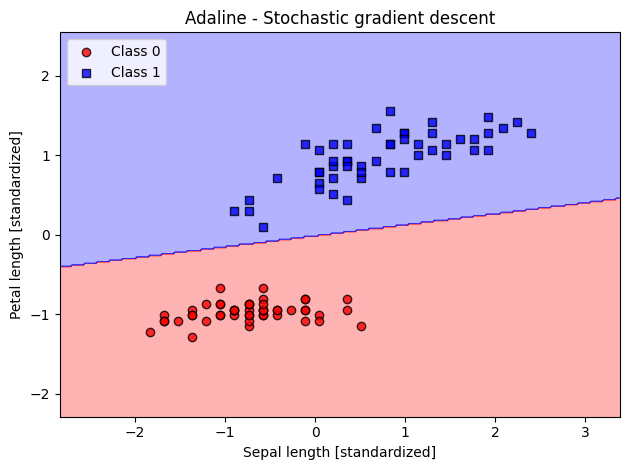

In [ ]:
ada_sgd = AdalineSGD(n_iter=15, eta=0.01, random_state=1)
ada_sgd.fit(X_std, y)

plot_decision_regions(X_std, y, classifier=ada_sgd)
plt.title('Adaline - Stochastic gradient descent')
plt.xlabel('Sepal length [standardized]')
plt.ylabel('Petal length [standardized]')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

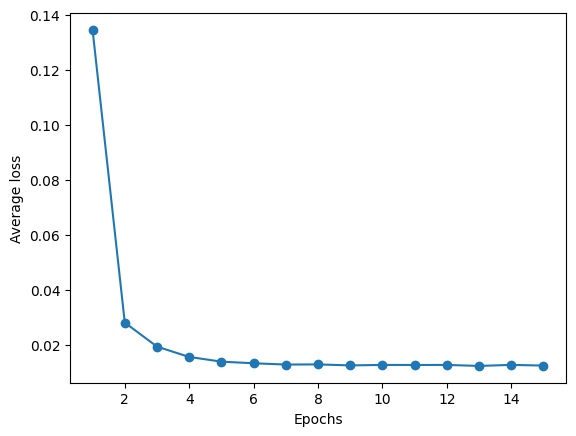

In [ ]:
plt.plot(range(1, len(ada_sgd.losses_) + 1), ada_sgd.losses_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Average loss')

plt.show()